# Noise, latency, and gain stability

**Scientific question.** An integrator AO loop is stable only for a bounded
combination of loop gain and frame latency, and its residual error depends on
the guide-star photon flux. Using the installed control-scan helpers over the
shared loop engine, where is the gain/latency stability boundary, and how does
the residual respond to loop gain?

`gain_delay_stability_map` and `gain_scan` are installed `shwfs_ao.control`
APIs; the notebook defines no loop of its own.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from shwfs_ao.backends.native.atmosphere import (
    FrozenFlowAtmosphere,
    FrozenFlowAtmosphereConfig,
)
from shwfs_ao.backends.native.shwfs import NativeShackHartmannOptics
from shwfs_ao.calibration import (
    DmActuatorProbeBasis,
    LeastSquaresReconstructor,
    calibrate_interaction_matrix,
)
from shwfs_ao.control import (
    IdentityCommandProjector,
    LeakyIntegratorController,
    LoopConfig,
    run_closed_loop,
)
from shwfs_ao.core.random import NamedRandomStreams
from shwfs_ao.detector.config import DetectorConfig
from shwfs_ao.dm import DMConfig, build_native_deformable_mirror
from shwfs_ao.wfs.shack_hartmann.geometry import build_shack_hartmann_geometry
from shwfs_ao.wfs.shack_hartmann.measurement import (
    build_detector_shack_hartmann_sensor,
)

from shwfs_ao.control import gain_delay_stability_map, gain_scan

In [2]:
# Fast-smoke contract (AO-REF-019): fast CI injects `FAST_SMOKE = True`
# right after this tagged cell; the committed outputs below are always
# the full study (FAST_SMOKE = False), executed by the scheduled lane.
FAST_SMOKE = False

In [3]:
SEED = 20240517
TELESCOPE_DIAMETER_M = 1.0
WFS_WAVELENGTH_M = 700e-9
GAINS = (0.2, 0.6, 1.0) if FAST_SMOKE else (0.2, 0.4, 0.6, 0.8, 1.0)
LATENCIES = (0, 1) if FAST_SMOKE else (0, 1, 2)
N_STEPS = 6 if FAST_SMOKE else 16

## Configuration

In [4]:
geometry = build_shack_hartmann_geometry(
    telescope_diameter_m=TELESCOPE_DIAMETER_M,
    pupil_shape=(60, 60),
    n_lenslets_across=6,
    min_fill_fraction=0.4,
)
optics = NativeShackHartmannOptics(geometry, WFS_WAVELENGTH_M, pad_factor=8)
sensor = build_detector_shack_hartmann_sensor(
    geometry,
    optics,
    DetectorConfig(photons_per_subap_frame=2e4),
    wfs_wavelength_m=WFS_WAVELENGTH_M,
    random_streams=NamedRandomStreams(SEED),
)
mirror = build_native_deformable_mirror(
    geometry.x_m,
    geometry.y_m,
    geometry.pupil_mask,
    DMConfig(
        telescope_diameter_m=TELESCOPE_DIAMETER_M,
        n_actuators_across=7,
        coupling_width_pitch=0.35,
        stroke_limit_nm=20000.0,
    ),
)
interaction = calibrate_interaction_matrix(
    DmActuatorProbeBasis(mirror),
    sensor,
    amplitude_m=25e-9,
    random_streams=NamedRandomStreams(SEED).scoped("calibration-probe"),
    include_noise=False,
)
atmosphere = FrozenFlowAtmosphere(
    FrozenFlowAtmosphereConfig(
        grid_size=geometry.pupil_shape[0],
        delta_m=geometry.pupil_geometry.pixel_spacing_xy_m[0],
        pupil_diameter_m=TELESCOPE_DIAMETER_M,
        r0_m=0.4,
        outer_scale_m=25.0,
        wind_m_per_s=(6.0, 0.0),
        root_seed=SEED,
    ),
    pupil_mask=geometry.pupil_mask,
)
base_config = LoopConfig(
    n_steps=N_STEPS, gain=0.5, leak=0.0, latency_frames=0,
    frame_rate_hz=1000.0, root_seed=SEED,
)
reconstructor = LeastSquaresReconstructor(interaction, min_valid_fraction=0.5, min_rank=1)
projector = IdentityCommandProjector(mirror.actuator_ids)

## Simulation call

In [5]:
stability = gain_delay_stability_map(
    GAINS,
    LATENCIES,
    base_config,
    random_streams=NamedRandomStreams(SEED),
    atmosphere=atmosphere,
    wfs=sensor,
    dm=mirror,
    interaction_matrix=interaction,
    reconstructor=reconstructor,
    command_projector=projector,
    include_noise=False,
)

def steady_residual(history):
    residual = np.asarray(history.post_update_residual_opd_rms_m, dtype=float)
    return float(np.mean(residual[N_STEPS // 2:]))

open_loop_rms = float(np.mean(atmosphere_rms := [
    np.mean(next(iter(stability.values())).open_loop_opd_rms_m)
]))
residual_map = np.array(
    [[steady_residual(stability[(g, d)]) for g in GAINS] for d in LATENCIES]
)

## Diagnostic table

In [6]:
open_loop = float(np.mean(next(iter(stability.values())).open_loop_opd_rms_m))
table = pd.DataFrame(
    residual_map / open_loop,
    index=[f"latency {d} frame(s)" for d in LATENCIES],
    columns=[f"gain {g:.1f}" for g in GAINS],
)
print(f"open-loop residual RMS: {open_loop * 1e9:.1f} nm "
      "(values below are residual / open-loop)")
table

open-loop residual RMS: 169.6 nm (values below are residual / open-loop)


,gain 0.2,gain 0.4,gain 0.6,gain 0.8,gain 1.0
latency 0 frame(s),0.663619,0.653986,0.652430,0.651938,0.651873
latency 1 frame(s),0.667197,0.659378,0.658570,0.673230,0.858453
latency 2 frame(s),0.674800,0.682029,0.814075,1.486471,2.810883


## Plot

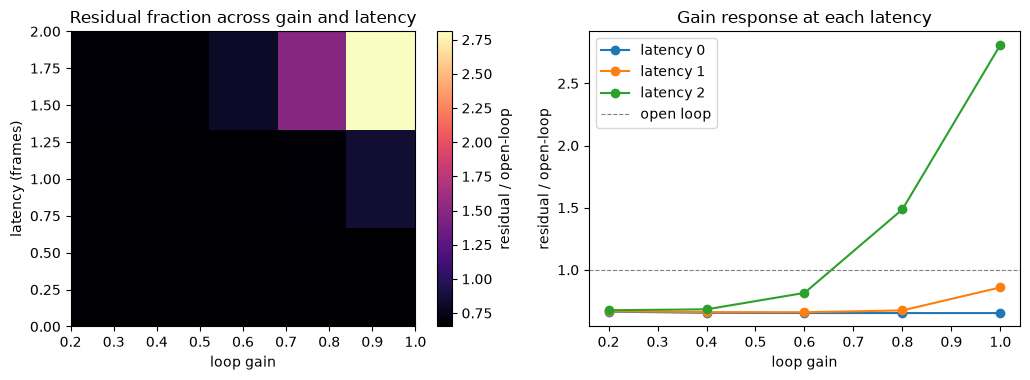

In [7]:
figure, (left, right) = plt.subplots(1, 2, figsize=(10.4, 3.9))
image = left.imshow(
    residual_map / open_loop, origin="lower", aspect="auto", cmap="magma",
    extent=[GAINS[0], GAINS[-1], LATENCIES[0], LATENCIES[-1]],
)
left.set_xlabel("loop gain")
left.set_ylabel("latency (frames)")
left.set_title("Residual fraction across gain and latency")
figure.colorbar(image, ax=left, label="residual / open-loop")
for latency in LATENCIES:
    row = [steady_residual(stability[(g, latency)]) / open_loop for g in GAINS]
    right.plot(GAINS, row, "o-", label=f"latency {latency}")
right.axhline(1.0, color="0.5", linewidth=0.8, linestyle="--", label="open loop")
right.set_xlabel("loop gain")
right.set_ylabel("residual / open-loop")
right.set_title("Gain response at each latency")
right.legend()
figure.tight_layout()
plt.show()

## Interpretation

At zero latency the residual keeps falling as the gain rises across this range,
but adding frame delay pulls the stable operating point down to lower gains: at
two frames of latency the higher gains stop helping and the residual rises
again as the loop approaches its stability boundary. This is the classic
gain–delay trade that fixes the usable bandwidth of a real-time AO controller;
the safe operating point is a gain high enough to reject turbulence but low
enough to stay clear of the boundary at the system's latency.

## Limitations

- A short deterministic run without measurement noise isolates the control
  dynamics; the photon term would raise the low-gain floor.
- The stability boundary is read from residual growth, not a formal transfer-
  function analysis.
- One realization per operating point; production maps average over seeds.